In [1]:
%load_ext autoreload
%autoreload 2

In [45]:
import pickle, h5py, os, glob
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import jax.numpy as jnp
import matplotlib.pyplot as plt

from sobol_seq import i4_sobol

# preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# inference
from msi.gaussian_mixture.gaussian_mixture_model import ConditionalGMM

from msi.gaussian_likelihood.dense_emulator import DenseEmulator

from pzflow import Flow
from pzflow.bijectors import ShiftBounds, RollingSplineCoupling, Chain
from pzflow.distributions import CentBeta13
from sklearn.model_selection import train_test_split

# utils
from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters, files

In [3]:
params = ["Om", "s8", "Aia"]

grid_dir = "/global/cfs/cdirs/des/vajani/combined-probes/output/Weak_Lensing/grid/Power_Spectra/dictionaries"
fidu_dir = "/global/cfs/cdirs/des/vajani/combined-probes/output/Weak_Lensing/fiducial/noisy/Power_spectra"
out_dir = "/pscratch/sd/a/athomsen/run_files/v3/power_spectra"

conf = files.load_config()
# l_mins = conf["analysis"]["scale_cuts"]["lensing"]["l_min"]
# l_maxs = conf["analysis"]["scale_cuts"]["lensing"]["l_max"]

l_mins = [30 for _ in range(4)]
l_maxs = [1600 for _ in range(4)]

with h5py.File("/global/homes/a/athomsen/multiprobe-simulation-forward-model/data/CosmoGridV1_metainfo.h5", "r") as f:
    cosmogrid_info = f["parameters/grid"][:]

# lensing only

## load the grid from Virginia's files

### fiducial

In [4]:
fidu_index = []
fidu_cls = []

for i in range(4):
    for j in range(4):
        if i <= j:
            bin_num = f"{i+1}x{j+1}"
            print(f"Loading bin_num = {bin_num}")

            # load ells
            centers = np.load(f'/global/cfs/cdirs/des/vajani/Cori/DESY3/SUMMARY/CENTERS_mode=E_stat=CrossCLs_tomo={bin_num}.npy').reshape(32)
            
            # scale cuts
            l_min = l_mins[i]
            l_max = l_maxs[i]
            l_cut = (l_min < centers) & (centers < l_max)
            n_summary = np.count_nonzero(l_cut)
            print(f"Using scale cuts l_min = {l_min}, l_max = {l_max}, which results in Cls of size {n_summary}")

            # load cls from .h5
            fidu_file_list = glob.glob(fidu_dir + f"/bin{bin_num}/WL_index_*_DESy3_fiducial_???.tfrecord.h5")
            print(f"found {len(fidu_file_list)} .h5 files")

            current_index = []
            current_cls = []

            for fidu_file in fidu_file_list:
                with h5py.File(fidu_file, "r") as f:
                    current_index.append(f["power_spectrum"].attrs["index"][0,0])
                    current_cls.append(f["power_spectrum"][:])
                    
            current_index = np.asarray(current_index)
            current_cls = np.asarray(current_cls)
            
            # every example index must be unique
            assert len(np.unique(current_index)) == len(fidu_file_list)

            # sort
            i_sorted = np.argsort(current_index)
            current_index = current_index[i_sorted]
            current_cls = current_cls[i_sorted]
            
            # apply scale cut
            current_cls = current_cls[:,l_cut]
            
            # collect in lists
            fidu_index.append(current_index)
            fidu_cls.append(current_cls)

# collect the different cosmologies
fidu_index = np.stack(fidu_index, axis=-1)
fidu_cls = np.concatenate(fidu_cls, axis=-1)

print(f"\nfidu_index.shape = {fidu_index.shape}")
print(f"fidu_cls.shape = {fidu_cls.shape}")

Loading bin_num = 1x1
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
found 750 .h5 files
Loading bin_num = 1x2
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
found 750 .h5 files
Loading bin_num = 1x3
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
found 750 .h5 files
Loading bin_num = 1x4
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
found 750 .h5 files
Loading bin_num = 2x2
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
found 750 .h5 files
Loading bin_num = 2x3
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
found 750 .h5 files
Loading bin_num = 2x4
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
found 750 .h5 files
Loading bin_num = 3x3
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
found 750 .h5 files
Loading bin_num = 3x4
Using scale cuts l_min = 30, l_max = 1600,

### grid

In [10]:
n_params = len(params)
n_examples = 16
n_summary = 32

# Om, s8, Aia
grid_theta = []
grid_cls = []

n_summaries = []

for i in range(4):
    for j in range(4):
        if i <= j:
            bin_num = f"{i+1}x{j+1}"
            print(f"Loading bin_num = {bin_num}")
                        
            # load grid cls
            with open(os.path.join(grid_dir, f'bin{bin_num}/power_spec_dict_bin{bin_num}.pickle'), 'rb') as f:
                current_dict = pickle.load(f)
            
            # load ells
            centers = np.load(f'/global/cfs/cdirs/des/vajani/Cori/DESY3/SUMMARY/CENTERS_mode=E_stat=CrossCLs_tomo={bin_num}.npy').reshape(32)
            
            # scale cuts
            l_min = l_mins[i]
            l_max = l_maxs[i]
            l_cut = (l_min < centers) & (centers < l_max)
            n_summary = np.count_nonzero(l_cut)
            print(f"Using scale cuts l_min = {l_min}, l_max = {l_max}, which results in Cls of size {n_summary}")
            n_summaries.append(n_summary)
            
            # container
            current_cls = np.zeros((len(current_dict), n_examples, n_summary))

            # loop through the dictionary
            for k, (key, value) in enumerate(current_dict.items()):
                # value is a list of length n_examples that contains arrays of shape (32,)
                Cls = np.asarray(value)[:,l_cut]
                # Cls = np.asarray(value)

                # only save the cosmological parameters once
                if i == 0 and j == 0:
                    current_theta_list = key.replace("[", "").replace("]", "").strip().split(" ")
                    current_theta_list = list(filter(None, current_theta_list))
                    current_theta_list = [float(item) for item in current_theta_list] 
                    current_Om = current_theta_list[0]
                    

                    grid_theta.append(np.array(current_theta_list))
                    
                # # check otherwise
                # else:
                #     assert np.all(grid_theta[k] == current_theta_list)
                    
                current_cls[k] = np.stack(Cls, axis=0)
                
            grid_cls.append(current_cls)

# collect the different cosmologies
grid_theta = np.stack(grid_theta, axis=0)
grid_cls = np.concatenate(grid_cls, axis=-1)

print(f"\ngrid_theta.shape = {grid_theta.shape}")
print(f"grid_cls.shape = {grid_cls.shape}")

# remove the example axis
grid_cls = np.concatenate(grid_cls, axis=0)
grid_theta = np.repeat(grid_theta, grid_cls.shape[0]//grid_theta.shape[0], axis=0)

print(f"\ngrid_theta.shape = {grid_theta.shape}")
print(f"grid_cls.shape = {grid_cls.shape}")

Loading bin_num = 1x1
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
Loading bin_num = 1x2
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
Loading bin_num = 1x3
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
Loading bin_num = 1x4
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
Loading bin_num = 2x2
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
Loading bin_num = 2x3
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
Loading bin_num = 2x4
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
Loading bin_num = 3x3
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
Loading bin_num = 3x4
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26
Loading bin_num = 4x4
Using scale cuts l_min = 30, l_max = 1600, which results in Cls of size 26

grid_theta.shape = (2499, 3)


In [11]:
assert grid_cls.shape[1] == fidu_cls.shape[1]

In [12]:
# grid_cls = grid_cls[:, :16]
# fidu_cls = fidu_cls[:, :16]

### plot power spectra

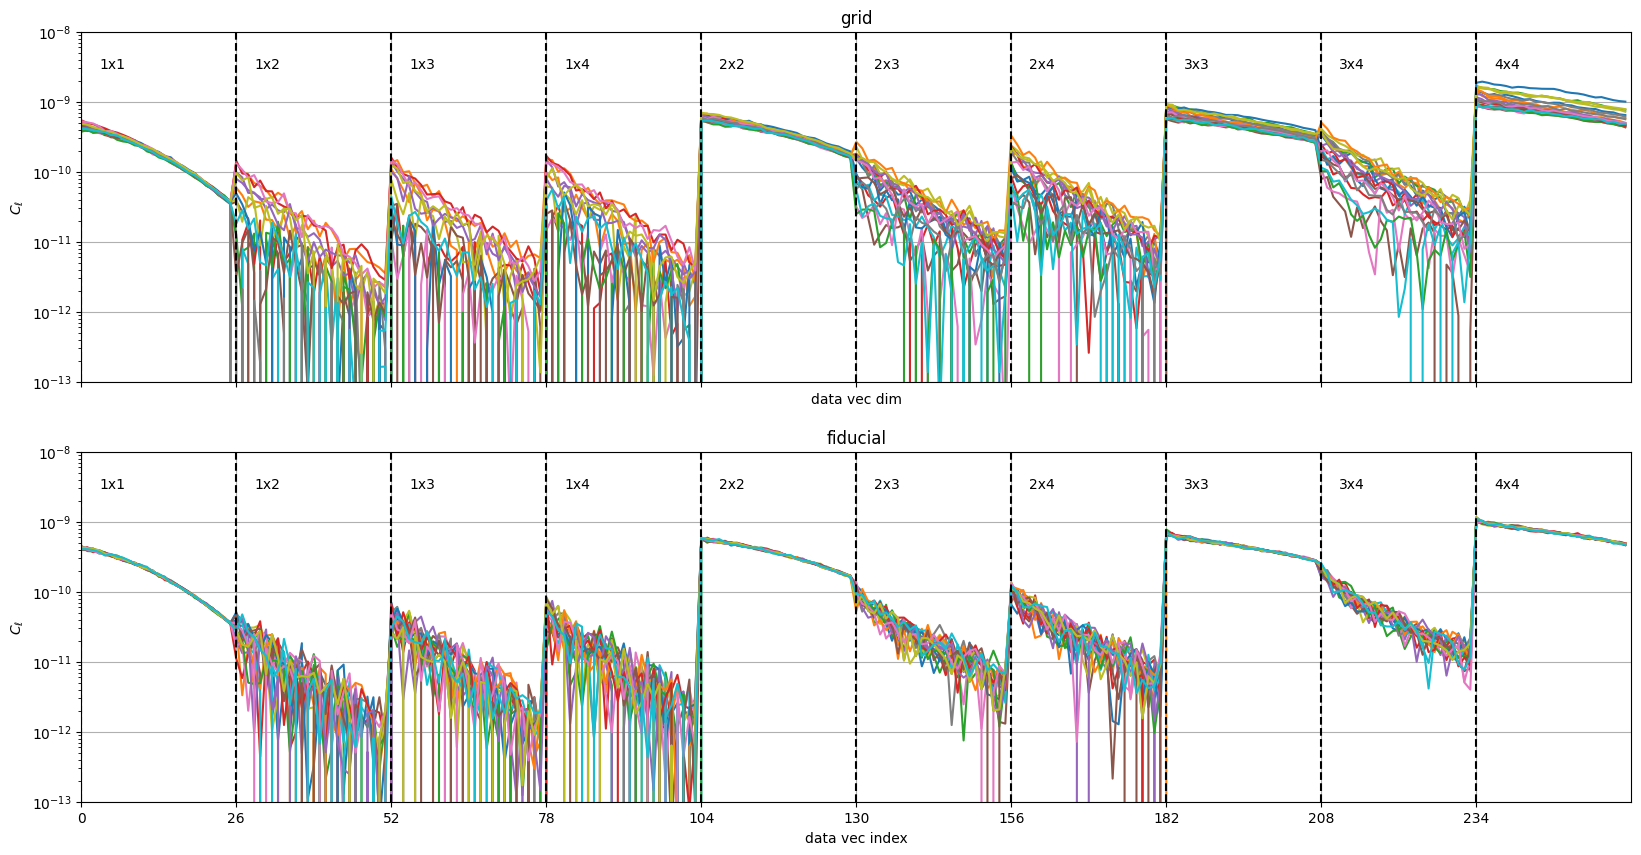

In [13]:
# grid
random_indices = np.random.choice(np.arange(grid_cls.shape[0]), 20)

fig, ax = plt.subplots(figsize=(20,10), nrows=2, sharex=True, sharey=True)

for i in random_indices:    
    ax[0].plot(grid_cls[i])
        
ax[0].set(xscale="linear", yscale="log", title=r"grid", xlim=(1, grid_cls.shape[1]), ylim=(1e-13, 1e-8), xlabel="data vec dim", ylabel=r"$C_\ell$")
ax[0].grid(True)

# fiducial
random_indices = np.random.choice(np.arange(fidu_cls.shape[0]), 20)

for i in random_indices:    
    ax[1].plot(fidu_cls[i])

ax[1].set(title=r"fiducial", xlabel="data vec index", ylabel=r"$C_\ell$")
ax[1].grid(True)

# cosmetics
x = 0
labels = ["1x1", "1x2", "1x3", "1x4", "2x2", "2x3", "2x4", "3x3", "3x4", "4x4"]
ticks = []
for i, n in enumerate(n_summaries):
    ax[0].axvline(x, color="k", linestyle="--")
    ax[1].axvline(x, color="k", linestyle="--")
    
    ax[0].text(x + 3, 3e-9, labels[i])
    ax[1].text(x + 3, 3e-9, labels[i])
    
    ticks.append(x)
    x += n
    
ax[0].set_xticks(ticks)
ax[1].set_xticks(ticks);

### observation

In [14]:
obs_cls = np.median(fidu_cls, axis=0, keepdims=True)
print(obs_cls.shape)

(1, 260)


### preprocessing

In [15]:
# PCA
pca = PCA(n_components=10)

grid_compressed_cls = pca.fit_transform(grid_cls)
fidu_compressed_cls = pca.transform(fidu_cls)
obs_compressed_cls = pca.transform(obs_cls)

print(f"grid shape before compression: {grid_cls.shape}")
print(f"grid shape after compression: {grid_compressed_cls.shape}")

# StandardScaler
scaler = StandardScaler()

grid_compressed_cls = scaler.fit_transform(grid_compressed_cls)
fidu_compressed_cls = scaler.transform(fidu_compressed_cls)
obs_compressed_cls = scaler.transform(obs_compressed_cls)

scaler = StandardScaler()

grid_standard_cls = scaler.fit_transform(grid_cls)
fidu_standard_cls = scaler.transform(fidu_cls)
obs_standard_cls = scaler.transform(obs_cls)

grid shape before compression: (39984, 260)
grid shape after compression: (39984, 10)


# inference with normalizing flow

In [29]:
flow_data = grid_compressed_cls
flow_conds = grid_theta
flow_obs = obs_compressed_cls

In [48]:
n_examples = flow_data.shape[0]
n_summaries = flow_data.shape[1]
summary_labels = [f"summary_{i}" for i in range(n_summaries)]

# build data frame
df_total = pd.DataFrame()

for i, summary_label in enumerate(summary_labels):
    df_total[summary_label] = flow_data[:,i]
    
for i, param in enumerate(params):
    df_total[param] = flow_conds[:,i]
    
df_train, df_val = train_test_split(df_total, test_size=0.1)

# repack the observation
obs_df = pd.DataFrame([flow_obs[0]], columns=summary_labels)

Training 100 epochs 
Loss:
(0) 25.3579  25.2933
(1) 9.7786  9.7284
(6) 6.3749  6.4524
(11) 5.5434  5.7457
(16) 5.5622  5.7651
(21) 5.3834  5.7195
(26) 4.9337  5.3175
(31) 4.9774  5.4029
(36) 4.8753  5.3491
(41) 4.8764  5.4945
(46) 4.6007  5.2431
(51) 4.8753  5.4882
(56) 4.5408  5.3134
(61) 4.5492  5.3480
(66) 4.3937  5.2961
(71) 4.5204  5.4254
(76) 4.6841  5.6871
(81) 4.3310  5.4081
(86) 4.3900  5.5190
(91) 4.2119  5.4654
(96) 4.1221  5.4328
(100) 4.1938  5.5239


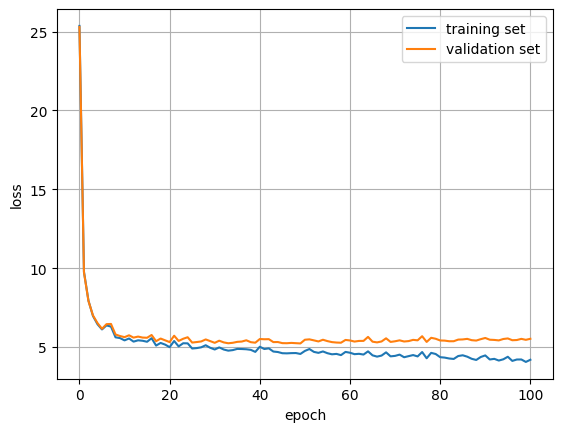

In [49]:
latent = CentBeta13(input_dim=n_summaries, B=5)
bijector = Chain(
    ShiftBounds(jnp.array(df_total[summary_labels].min(axis=0)), jnp.array(df_total[summary_labels].max(axis=0)), B=4),
    RollingSplineCoupling(n_summaries, B=5, n_conditions=n_params, hidden_dim=128),
)

flow = Flow(
    data_columns=summary_labels, 
    conditional_columns=params, 
    latent=latent,
    bijector=bijector,
)

# train
loss_train, loss_val = flow.train(df_train, df_val, verbose=True, epochs=100)

# plot
fig, ax = plt.subplots()
ax.plot(loss_train, label="training set")
ax.plot(loss_val, label="validation set")
ax.set(xlabel="epoch", ylabel="loss")
ax.legend()
ax.grid(True)

23-07-07 06:50:18      mcmc.py INF   Initial values in prior: True 


100%|██████████| 500/500 [04:28<00:00,  1.86it/s]


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

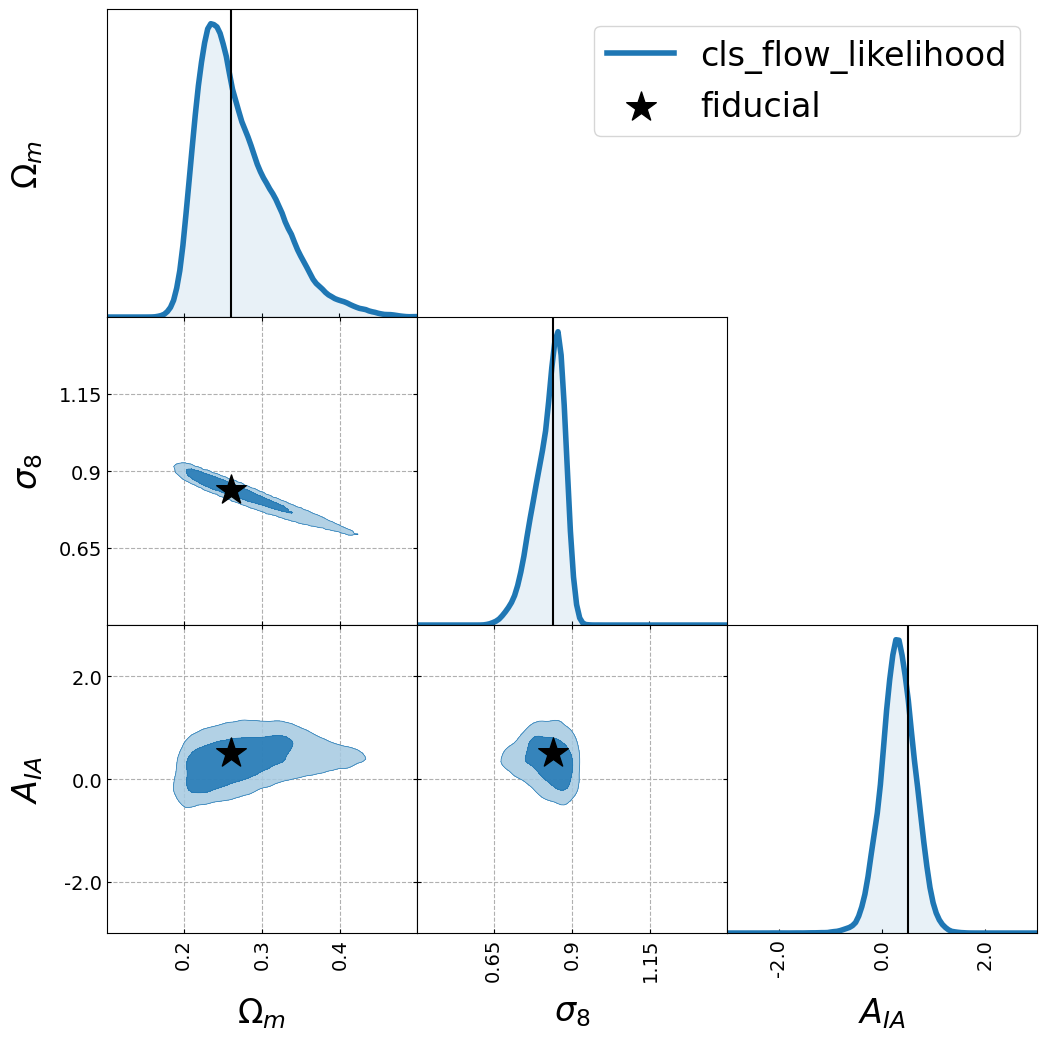

In [51]:
label = f"cls_flow_likelihood"

def log_likelihood(X): 
    # convert to dataframe
    X = pd.DataFrame(X, columns=params)
    X = X.join(obs_df, how="cross")

    # evaluate the normalizing flow
    log_prob = flow.log_prob(X)
    
    # enforce the prior
    log_prob = prior.log_posterior(X.loc[:,params], log_prob, params=params, conf=None)

    return log_prob

chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
    n_steps=500,
)

plotting.plot_chain(
    chain, 
    params, 
    out_dir=out_dir, 
    label=label,
)

# inference with mixture of Gaussians

In [52]:
x_gauss_mix = grid_theta

y_gauss_mix = grid_compressed_cls
obs_gauss_mix = obs_compressed_cls

# y_gauss_mix = grid_standard_cls
# obs_gauss_mix = obs_standard_cls

23-07-07 06:56:29 gaussian_mix INF   Created GMM model with n_params = 266248 
Model: "gaussian_mixture_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNoi  (None, 3)                0         
 se)                                                             
                                                                 
 dense (Dense)               (None, 256)               1024      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (N

epoch:  48%|████▊     | 238/500 [00:28<00:29,  8.98it/s, loss=-11.6, val_loss=-11.1, lr=None]

Restoring model weights from the end of the best epoch: 139.


epoch:  48%|████▊     | 239/500 [00:28<00:28,  9.24it/s, loss=-11.6, val_loss=-11.4, lr=None]

Epoch 239: early stopping


epoch:  48%|████▊     | 239/500 [00:28<00:31,  8.35it/s, loss=-11.6, val_loss=-11.4, lr=None]

23-07-07 06:56:58 gaussian_mix INF   Finished training 


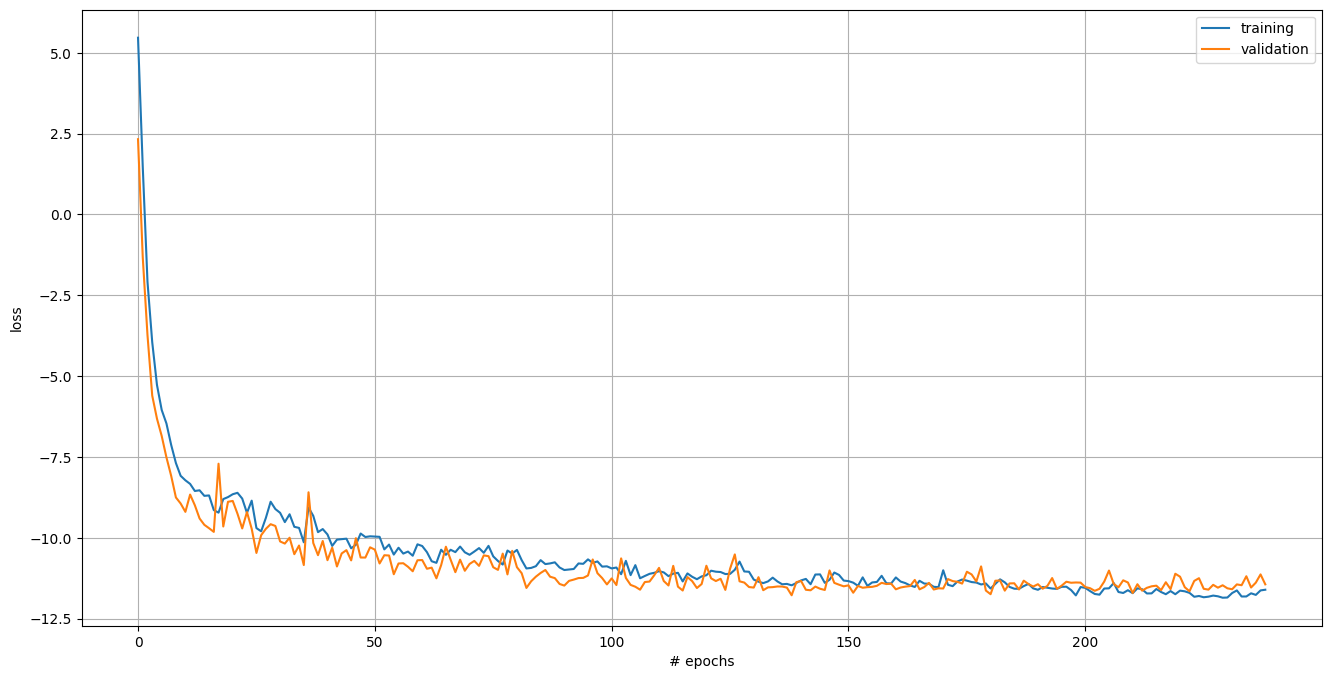

In [53]:
# p(y | x) <=> p(cls | theta)
model = ConditionalGMM(
    # theta
    x_dim=x_gauss_mix.shape[1],
    # cls
    y_dim=y_gauss_mix.shape[1],
    out_dir=None,
    n_gaussians=4,
    u_units=256,
    n_layers=3,
    activation="relu",
    input_noise_sig=0.0,
    tune_hyperparams=False,
)

# training
fit_history = model.fit(
    x=x_gauss_mix,
    y=y_gauss_mix,
    epochs=500,
    batch_size=2499,
    early_stopping_callback=True,
    learning_rate_callback=False,
)

# plot
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(fit_history.history["loss"], label="training")
ax.plot(fit_history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear")
ax.grid(True)

## MCMC and plot

23-07-07 06:56:58      mcmc.py INF   Initial values in prior: True 


100%|██████████| 500/500 [01:11<00:00,  7.01it/s]


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

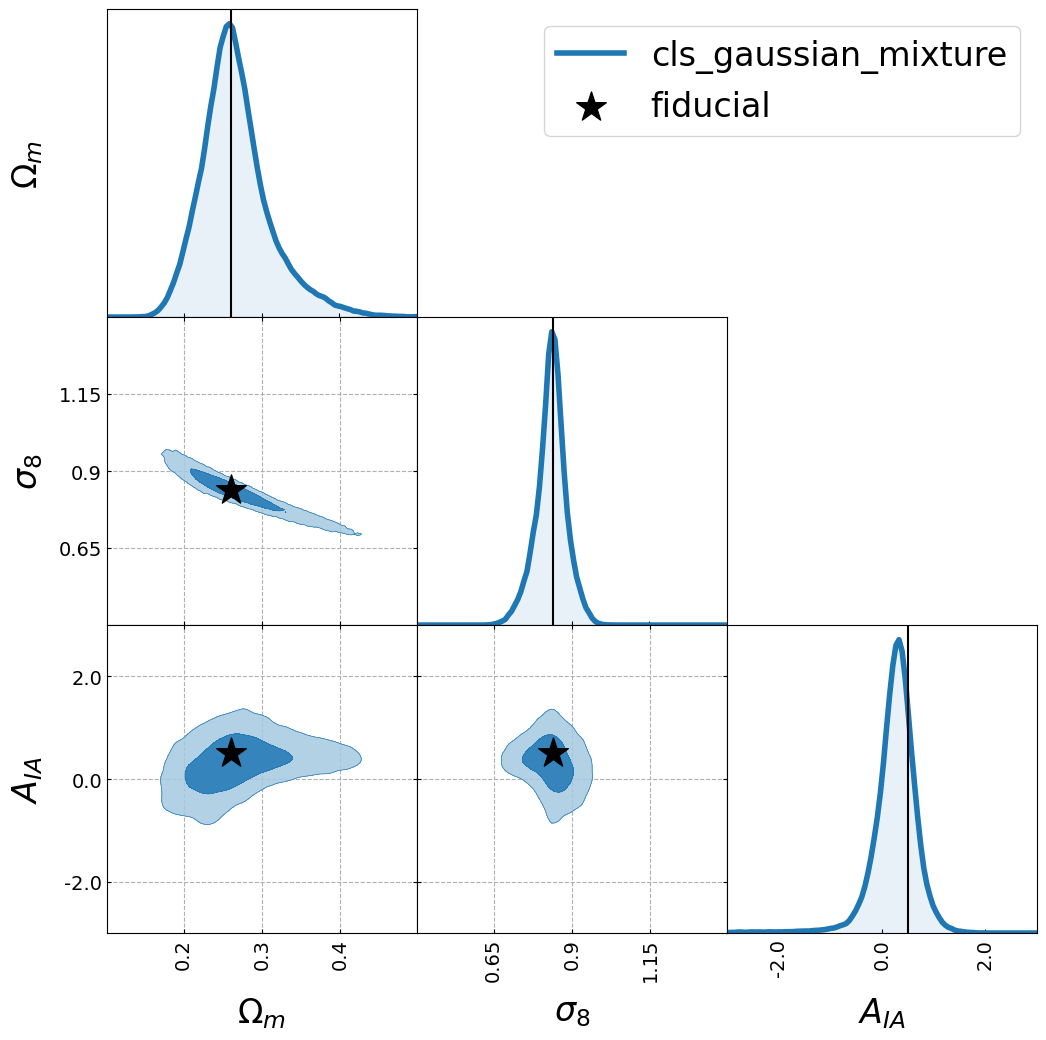

In [54]:
label = f"cls_gaussian_mixture"

tf_pred = tf.cast(obs_gauss_mix, dtype=tf.float64)
# tf_pred = tf.cast(obs_cls[np.newaxis,:], dtype=tf.float32)

def log_likelihood(X): 
    # evaluate the normal distribution
    log_prob = model.log_likelihood(X, tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)
    

    return log_prob

chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
    n_steps=500,
)

plotting.plot_chain(
    chain, 
    params, 
    out_dir=out_dir, 
    label=label,
)

# inference with Gaussian likelihood

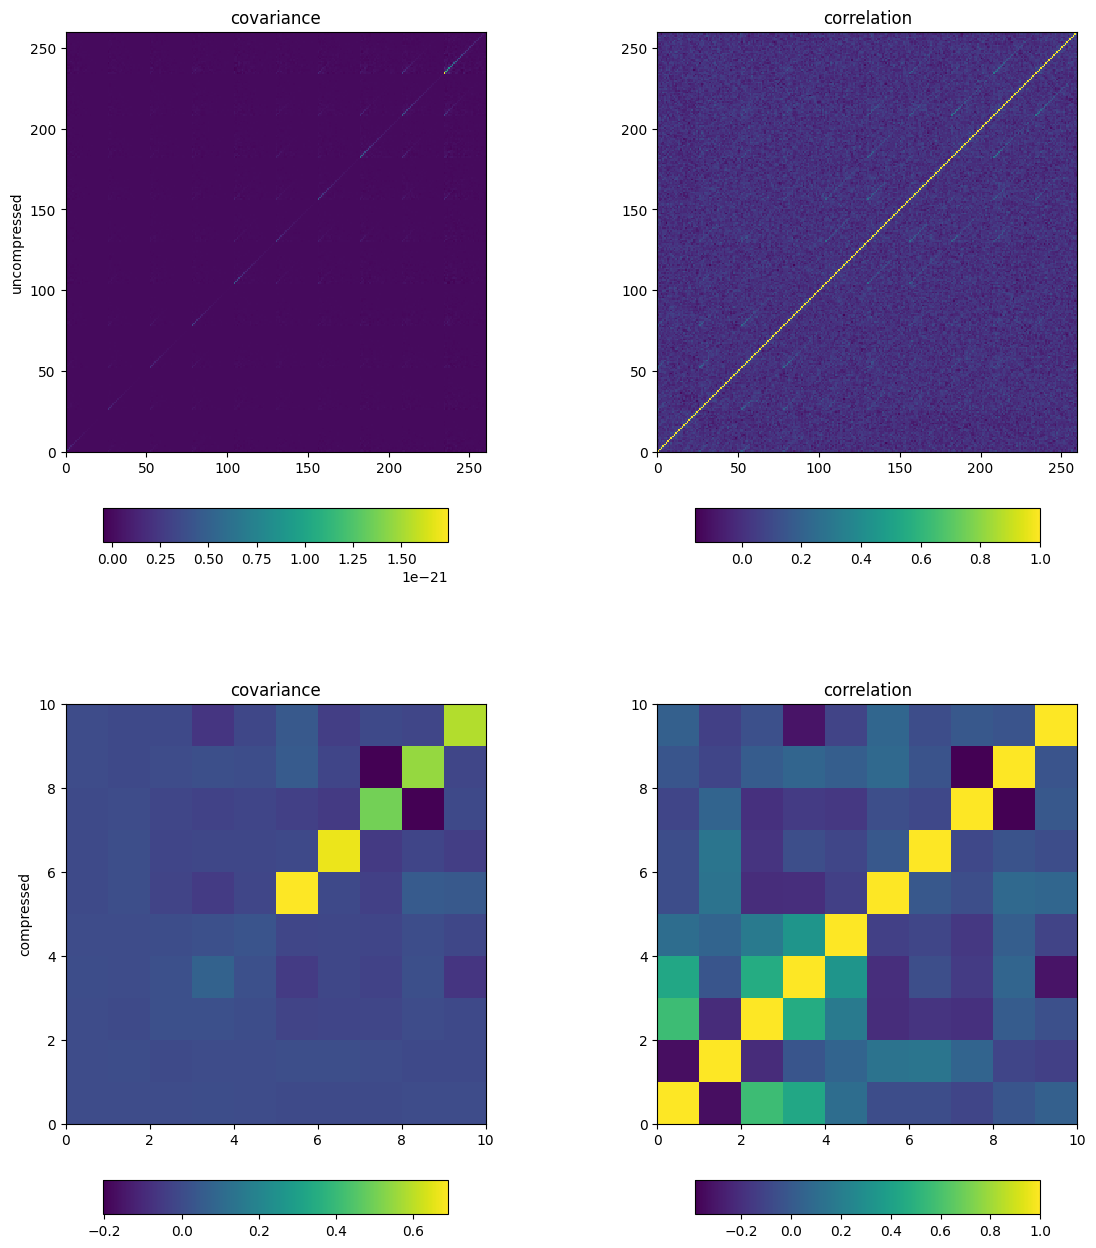

In [55]:
fidu_cov = np.cov(fidu_cls, rowvar=False)
fidu_corr = np.corrcoef(fidu_cls, rowvar=False)

# standardized
fidu_standard_cov = np.cov(fidu_standard_cls, rowvar=False)
fidu_standard_corr = np.corrcoef(fidu_standard_cls, rowvar=False)

# compressed
fidu_compressed_cov = np.cov(fidu_compressed_cls, rowvar=False)
fidu_compressed_corr = np.corrcoef(fidu_compressed_cls, rowvar=False)

# plot
fig, ax = plt.subplots(figsize=(14,16), ncols=2, nrows=2)

# uncompressed

# covariance
im = ax[0,0].pcolormesh(fidu_cov)
ax[0,0].set(title="covariance", ylabel="uncompressed")
ax[0,0].set_aspect("equal")

fig.colorbar(im, ax=ax[0,0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# correlation
im = ax[0,1].pcolormesh(fidu_corr)
ax[0,1].set(title="correlation")
ax[0,1].set_aspect("equal")

fig.colorbar(im, ax=ax[0,1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# compressed

# covariance
im = ax[1,0].pcolormesh(fidu_compressed_cov)
ax[1,0].set(title="covariance", ylabel="compressed")
ax[1,0].set_aspect("equal")

fig.colorbar(im, ax=ax[1,0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# correlation
im = ax[1,1].pcolormesh(fidu_compressed_corr)
ax[1,1].set(title="correlation")
ax[1,1].set_aspect("equal")

fig.colorbar(im, ax=ax[1,1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

In [57]:
x_gauss_like = grid_theta

y_gauss_like = grid_standard_cls
cov_gauss_like = fidu_standard_cov
obs_gauss_like = obs_standard_cls

# y_gauss_like = grid_compressed_cls
# cov_gauss_like = fidu_compressed_cov
# obs_gauss_like = obs_compressed_cls

23-07-07 06:59:17 dense_emulat INF   Preprocessing scalers have been successfully fit 
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 3)]               0         
                                                                 
 tf.math.subtract (TFOpLambd  (None, 3)                0         
 a)                                                              
                                                                 
 tf.math.truediv (TFOpLambda  (None, 3)                0         
 )                                                               
                                                                 
 dense_5 (Dense)             (None, 1024)              4096      
                                                                 
 dropout_4 (Dropout)         (None, 1024)              0         
                                        

epoch:  47%|████▋     | 469/1000 [00:53<01:00,  8.73it/s, loss=0.239, val_loss=0.187, lr=None]

Restoring model weights from the end of the best epoch: 370.


epoch:  47%|████▋     | 470/1000 [00:53<00:59,  8.84it/s, loss=0.239, val_loss=0.186, lr=None]

Epoch 470: early stopping


epoch:  47%|████▋     | 470/1000 [00:53<01:00,  8.83it/s, loss=0.239, val_loss=0.186, lr=None]


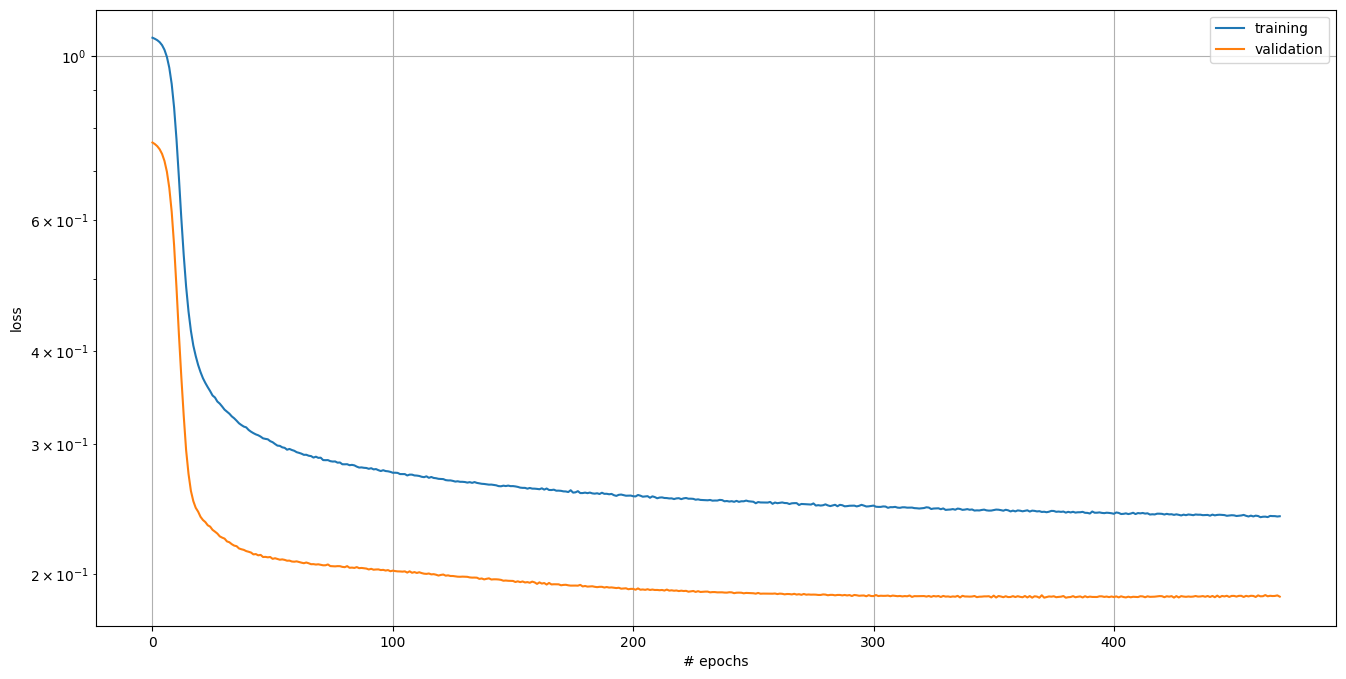

In [58]:
# f(x) = y
emu = DenseEmulator(
    x=tf.cast(x_gauss_like, dtype=tf.float32), 
    y=tf.cast(y_gauss_like, dtype=tf.float32),
    n_units=1024, 
    n_layers=5, 
    dropout_rate=0.2,
    learning_rate=1e-5,
)

# training
history = emu.fit(
    x=tf.cast(x_gauss_like, dtype=tf.float32), 
    y=tf.cast(y_gauss_like, dtype=tf.float32),
    validation_split=0.2, 
    batch_size=2499,
    epochs=1000,
    early_stopping_callback=True,
    # learning_rate_callback=False,
)

# plot
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(history.history["loss"], label="training")
ax.plot(history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="log")
ax.grid(True)

## MCMC and plot

23-07-07 07:00:15      mcmc.py INF   Initial values in prior: True 


100%|██████████| 1000/1000 [01:28<00:00, 11.29it/s]

23-07-07 07:01:52      mcmc.py WAR   Not saving the chain 


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

23-07-07 07:01:53  plotting.py WAR   Not saving the plot 


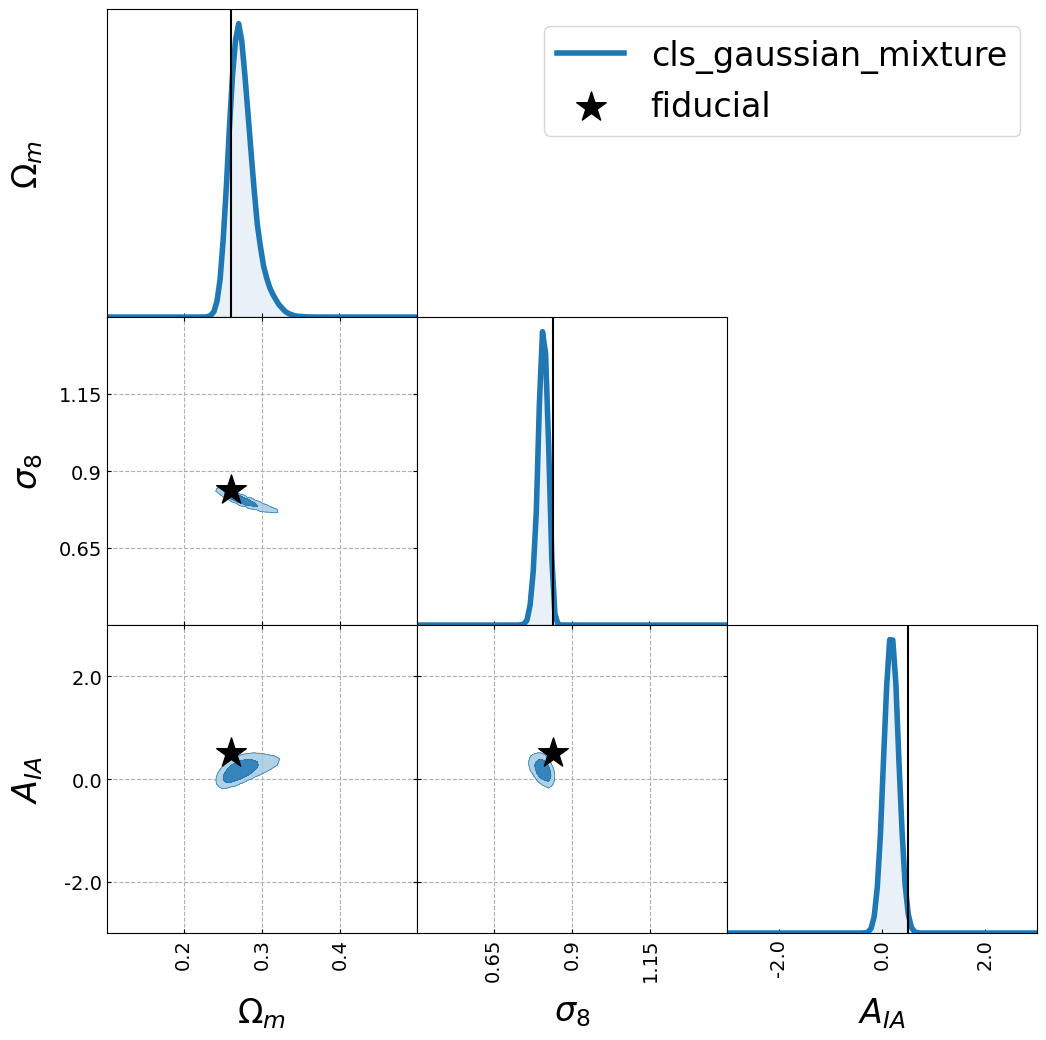

In [59]:
tf_cholesky = tf.linalg.cholesky(tf.cast(cov_gauss_like, dtype=tf.float32))
tf_pred = tf.cast(obs_gauss_like, dtype=tf.float32)

def log_likelihood(X): 
    # X = emu.scale_forward_x(X)
    normal = tfp.distributions.MultivariateNormalTriL(
        loc=emu(X), 
        scale_tril=tf_cholesky,
    )

    # evaluate the normal distribution
    log_prob = normal.log_prob(tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)

    return log_prob

chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=None,
    label=label,
)

plotting.plot_chain(
    chain, 
    params, 
    out_dir=None, 
    label=label,
)